### NAME: MUHAMMAD DANYAL KHALIL
### REG NO: 22JZELE0473
### UNIVERSITY: UET PESHAWAR (NOWSHERA CAMPUS)
### DEPARTMENT: ELECTRICAL (POWER)
# Lab 9: Augmentation and Keras ImageDataGenerator

**Course:** Machine Learning Lab  
**Topic:** Training a CNN with image augmentation

## Lab Objective
The objective of this lab is to apply Keras `ImageDataGenerator` for image augmentation and train a CNN that can generalize better on unseen images.


## 1. Import Required Libraries
The imports include Keras model layers, optimizers, image augmentation tools, checkpoint callbacks, plotting utilities, and evaluation functions.


In [2]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

## 2. Define Checkpoint Path
The checkpoint file name includes epoch and validation loss so the best training result can be identified and saved.


In [3]:
checkpoints = r'H:\DRIVE D DATA\UET\8th Semester\Machine Learning Lab\lab no 9\checkpoint\ML Lab\lab13\\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

## 3. Define Dataset Directories
These paths identify the training, validation, and testing image folders used for CNN training and evaluation.


In [4]:
train_dir = r'H:\DRIVE D DATA\UET\8th Semester\Machine Learning Lab\lab no 7\labno7\train'
validation_dir = r'H:\DRIVE D DATA\UET\8th Semester\Machine Learning Lab\lab no 7\labno7\validation'
test_dir = r'H:\DRIVE D DATA\UET\8th Semester\Machine Learning Lab\lab no 7\labno7\test'

## 4. Build the CNN Model
The CNN extracts image features using convolution and pooling layers, then classifies images using dense layers and a final softmax output.


In [5]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(4, activation='sigmoid'))

c:\Users\Lenovo\anaconda3\envs\DSP\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 5. Display Model Summary
The model summary confirms the architecture and shows the number of parameters in each layer.


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,088,452 (49.93 MB)

 Trainable params: 13,088,452 (49.93 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Compile the Model
The model is compiled with categorical crossentropy because this is a multi-class image classification problem.


In [7]:
model.compile(loss='categorical_crossentropy', optimizer=optimizers.RMSprop(learning_rate=1e-4), metrics=['acc'])

## 7. Configure Image Augmentation
The augmentation generator applies transformations such as rotation, shifting, shearing, zooming, and flipping to create varied training samples.


In [8]:
train_datagen = ImageDataGenerator(
                                    rescale=1./255,
                                    rotation_range=40,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range=0.2,
                                    zoom_range=0.2,
                                    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
                                                    train_dir,
                                                    target_size=(256, 256),
                                                    batch_size=32,
                                                    class_mode='categorical')

validation_generator = test_datagen.flow_from_directory(
                                                        validation_dir,
                                                        target_size=(256, 256),
                                                        batch_size=32,
                                                        class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


## 8. Load Images with Generators
The generators read images from folders, resize them, rescale pixel values, and create batches for training and validation.


In [9]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32,class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(validation_dir,target_size=(256, 256),batch_size=32,class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


## 9. Configure Checkpoint Callback
The checkpoint callback saves the best model during training based on validation loss.


In [10]:
EpochCheckpoint = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
callbacks = [EpochCheckpoint]

## 10. Train the Augmented CNN
The model trains on augmented images and validates on separate validation data after each epoch.


In [11]:
model_history = model.fit(train_generator,
                         validation_data =validation_generator,
                         steps_per_epoch=train_generator.n//train_generator.batch_size,
                         validation_steps = validation_generator.n//validation_generator.batch_size,
                         epochs = 2,
                         callbacks = callbacks)

Epoch 1/2
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.3964 - loss: 1.2834
Epoch 1: val_loss improved from None to 0.67855, saving model to H:\DRIVE D DATA\UET\8th Semester\Machine Learning Lab\lab no 9\checkpoint\ML Lab\lab13\\E1-cp-0001-loss0.68.h5



Epoch 1: finished saving model to H:\DRIVE D DATA\UET\8th Semester\Machine Learning Lab\lab no 9\checkpoint\ML Lab\lab13\\E1-cp-0001-loss0.68.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - acc: 0.5056 - loss: 1.1157 - val_acc: 0.7277 - val_loss: 0.6786
Epoch 2/2
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.7753 - loss: 0.6004
Epoch 2: val_loss did not improve from 0.67855
50/50 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - acc: 0.7594 - loss: 0.5751 - val_acc: 0.6562 - val_loss: 0.7412


## 11. Inspect Training History
The training history stores loss and accuracy values used to analyze model learning.


In [12]:
model_history.history

{'acc': [0.5056250095367432, 0.7593749761581421],
 'loss': [1.1157225370407104, 0.5751044750213623],
 'val_acc': [0.7276785969734192, 0.65625],
 'val_loss': [0.6785539984703064, 0.7412248253822327]}

## 12. Plot Accuracy and Loss
These plots make it easier to compare training and validation performance and identify overfitting or underfitting.


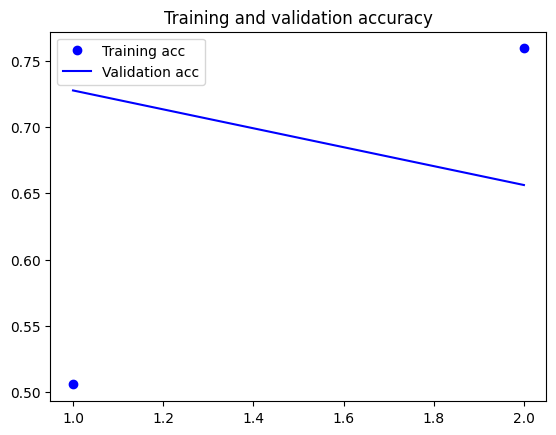

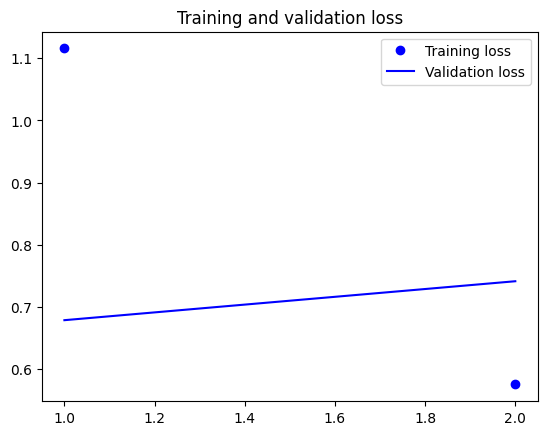

<Figure size 640x480 with 0 Axes>

In [13]:
acc = model_history.history['acc']
val_acc = model_history.history['val_acc']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()
plt.savefig(r'H:\DRIVE D DATA\UET\8th Semester\Machine Learning Lab\lab no 9\model_Accuracy.png')

## 13. Load Best Model and Predict Test Images
The saved model is loaded and tested on unseen images. The predicted class labels are compared with actual labels.


Found 200 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 398ms/step


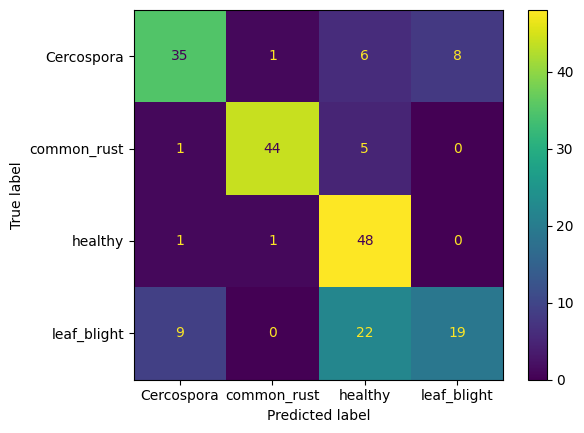

In [14]:
model = load_model(r'H:\DRIVE D DATA\UET\8th Semester\Machine Learning Lab\lab no 9\checkpoint\ML Lab\Lab13\E1-cp-0001-loss0.62.h5')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=32, shuffle=False, class_mode='categorical')
label=test_generator.labels
preds=model.predict(test_generator)
pred = np.argmax(preds, axis = 1)
cm = confusion_matrix(label, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Cercospora', 'common_rust','healthy', 'leaf_blight'])
disp.plot()
plt.show()
#plt.savefig(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\confusion_matrics.jpg')

## 14. Classification Report
The classification report gives precision, recall, F1-score, and support for each image class.


In [15]:
print(classification_report(label, pred, target_names=['Cercospora', 'common_rust','healthy', 'leaf_blight']))

              precision    recall  f1-score   support

  Cercospora       0.76      0.70      0.73        50
 common_rust       0.96      0.88      0.92        50
     healthy       0.59      0.96      0.73        50
 leaf_blight       0.70      0.38      0.49        50

    accuracy                           0.73       200
   macro avg       0.75      0.73      0.72       200
weighted avg       0.75      0.73      0.72       200



## Conclusion
This lab shows how image augmentation can improve CNN training by increasing data variety. Augmentation helps reduce overfitting and supports better generalization on test images.
